In [3]:
import pandas as pd
import glob 
import seaborn as sns
import matplotlib.pyplot as plt
import protfasta
import numpy as np
import os
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

In [4]:

def return_big_df(folder_path):
    dfs = []
    for path in glob.glob(folder_path):
        # Skip empty files
        if os.path.getsize(path) == 0:
            continue
        try:
            df = pd.read_csv(path, sep="\t", header=None, index_col=0).reset_index()
            dfs.append(df)
        except pd.errors.EmptyDataError:
            # Skip files that pandas considers empty
            continue
    if dfs:
        return pd.concat(dfs, ignore_index=True)
    else:
        # Return empty DataFrame if no valid files
        return pd.DataFrame()

In [5]:
old_SFARI_TF_dbd_coords = pd.read_csv("../soto_analysis/outputs/TFs_table_proteins.txt",sep = "\t")
old_SFARI_TF_dbd_coords.head()

,Unnamed: 0,1,2,uniprotID,ENSG,ENST,DBD_coords,AD_coords,RD_coords,Bif_coords,length
0,0,NaN,NaN,O14770,ENSG00000134138,ENST00000561208,276-338,340-477,NaN,NaN,1
1,1,NaN,NaN,O60479,ENSG00000064195,ENST00000434704,129-188,"199-263,2-91",NaN,NaN,1
2,2,NaN,NaN,O75840,ENSG00000118263,ENST00000309446,NA-NA,2-101,NaN,NaN,1
3,3,NaN,NaN,O94983,ENSG00000108509,ENST00000348066,30-155,"285-468,472-581",NaN,NaN,1
4,4,NaN,NaN,O95096,ENSG00000125820,ENST00000377142,128-187,220-273,NaN,NaN,1


In [6]:
all_TFs = pd.read_csv("../soto_analysis/outputs/all_TFs_table_proteins.txt", sep = "\t")
activator_TFs = all_TFs.dropna(subset = "AD_coords")
activator_TFs

,Unnamed: 0,1,2,uniprotID,ENSG,ENST,DBD_coords,AD_coords,RD_coords,Bif_coords,length
13,13,NaN,NaN,A6NJG6,NaN,ENST00000334384,79-135,142-315,NaN,NaN,1
27,27,NaN,NaN,A8MTJ6,NaN,ENST00000428390,145-234,369-420,NaN,NaN,1
33,33,NaN,NaN,A8MYZ6,NaN,ENST00000641094,89-178,382-491,NaN,NaN,1
45,45,NaN,NaN,O00570,NaN,ENST00000330949,51-119,125-391,NaN,NaN,1
48,48,NaN,NaN,O14627,NaN,ENST00000373514,174-230,32-131,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
1571,1571,NaN,NaN,Q9Y458,NaN,ENST00000373294,94-283,402-481,NaN,NaN,1
1582,1582,NaN,NaN,Q9Y5R6,NaN,ENST00000382276,72-118,172-251,NaN,NaN,1
1585,1585,NaN,NaN,Q9Y692,NaN,ENST00000294409,89-165,422-573,NaN,NaN,1
1587,1587,NaN,NaN,Q9Y6Q9,NaN,ENST00000371998,31-83,621-1424,NaN,NaN,1


In [7]:
zoonomia_domains = return_big_df("../soto_analysis/outputs/mutations/domains_zoonomia_all_TF_cds/*")
# Filter to activator TFs
# zoonomia_domains = zoonomia_domains[zoonomia_domains[7].isin(activator_TFs["ENST"])]
# Filter to SFARI TFs
zoonomia_domains = zoonomia_domains[zoonomia_domains[7].isin(old_SFARI_TF_dbd_coords["ENST"])]
zoonomia_domains_by_TF = zoonomia_domains.groupby([7, 3]).mean(numeric_only=True).reset_index()
zoonomia_domains_by_TF

,7,3,1,2,4,6,9,10,12,14,15,16
0,ENST00000056233,AD,2.618465e+07,2.618465e+07,NaN,1.0,2.618465e+07,2.618465e+07,1.0,2.618465e+07,2.618465e+07,1.774942
1,ENST00000056233,DBD,2.618552e+07,2.618552e+07,NaN,1.0,2.618552e+07,2.618552e+07,1.0,2.618552e+07,2.618552e+07,3.290381
2,ENST00000056233,IDR,2.617339e+07,2.617340e+07,NaN,1.0,2.617339e+07,2.617340e+07,1.0,2.617339e+07,2.617340e+07,1.730313
3,ENST00000239243,AD,1.747295e+08,1.747295e+08,NaN,1.0,1.747295e+08,1.747295e+08,1.0,1.747295e+08,1.747295e+08,4.469471
4,ENST00000239243,DBD,1.747293e+08,1.747293e+08,NaN,1.0,1.747293e+08,1.747293e+08,1.0,1.747293e+08,1.747293e+08,5.380322
...,...,...,...,...,...,...,...,...,...,...,...,...
130,ENST00000561208,DBD,3.697826e+07,3.697826e+07,NaN,-1.0,3.697826e+07,3.697826e+07,-1.0,3.697826e+07,3.697826e+07,6.151814
131,ENST00000561208,IDR,3.699815e+07,3.699815e+07,NaN,-1.0,3.699815e+07,3.699815e+07,-1.0,3.699815e+07,3.699815e+07,6.017769
132,ENST00000592199,AD,1.308877e+07,1.308877e+07,NaN,1.0,1.308877e+07,1.308877e+07,1.0,1.308877e+07,1.308877e+07,6.703129
133,ENST00000592199,DBD,1.302535e+07,1.302535e+07,NaN,1.0,1.302535e+07,1.302535e+07,1.0,1.302535e+07,1.302535e+07,6.263010


In [8]:
verteb_domains = return_big_df("/Users/sanjanakotha/Desktop/Staller_Lab/SFARI/soto_analysis/outputs/mutations/domains_100_verteb_all_TF_cds/*")
# Filter to activator TFs
# verteb_domains = verteb_domains[verteb_domains[7].isin(activator_TFs["ENST"])]
# Filter to SFARI TFs
verteb_domains = verteb_domains[verteb_domains[7].isin(old_SFARI_TF_dbd_coords["ENST"])]
verteb_domains_by_TF = verteb_domains.groupby([7, 3]).mean(numeric_only=True).reset_index()
verteb_domains_by_TF

,7,3,1,2,4,6,9,10,12,14,15,16
0,ENST00000056233,AD,2.618465e+07,2.618465e+07,NaN,1.0,2.618465e+07,2.618465e+07,1.0,2.618465e+07,2.618465e+07,1.135412
1,ENST00000056233,DBD,2.618552e+07,2.618552e+07,NaN,1.0,2.618552e+07,2.618552e+07,1.0,2.618552e+07,2.618552e+07,3.233809
2,ENST00000056233,IDR,2.617339e+07,2.617340e+07,NaN,1.0,2.617339e+07,2.617340e+07,1.0,2.617339e+07,2.617340e+07,0.857228
3,ENST00000239243,AD,1.747295e+08,1.747295e+08,NaN,1.0,1.747295e+08,1.747295e+08,1.0,1.747295e+08,1.747295e+08,3.991688
4,ENST00000239243,DBD,1.747293e+08,1.747293e+08,NaN,1.0,1.747293e+08,1.747293e+08,1.0,1.747293e+08,1.747293e+08,5.757166
...,...,...,...,...,...,...,...,...,...,...,...,...
130,ENST00000561208,DBD,3.697826e+07,3.697826e+07,NaN,-1.0,3.697826e+07,3.697826e+07,-1.0,3.697826e+07,3.697826e+07,6.759647
131,ENST00000561208,IDR,3.699815e+07,3.699815e+07,NaN,-1.0,3.699815e+07,3.699815e+07,-1.0,3.699815e+07,3.699815e+07,5.708611
132,ENST00000592199,AD,1.308877e+07,1.308877e+07,NaN,1.0,1.308877e+07,1.308877e+07,1.0,1.308877e+07,1.308877e+07,4.962744
133,ENST00000592199,DBD,1.302535e+07,1.302535e+07,NaN,1.0,1.302535e+07,1.302535e+07,1.0,1.302535e+07,1.302535e+07,6.206731


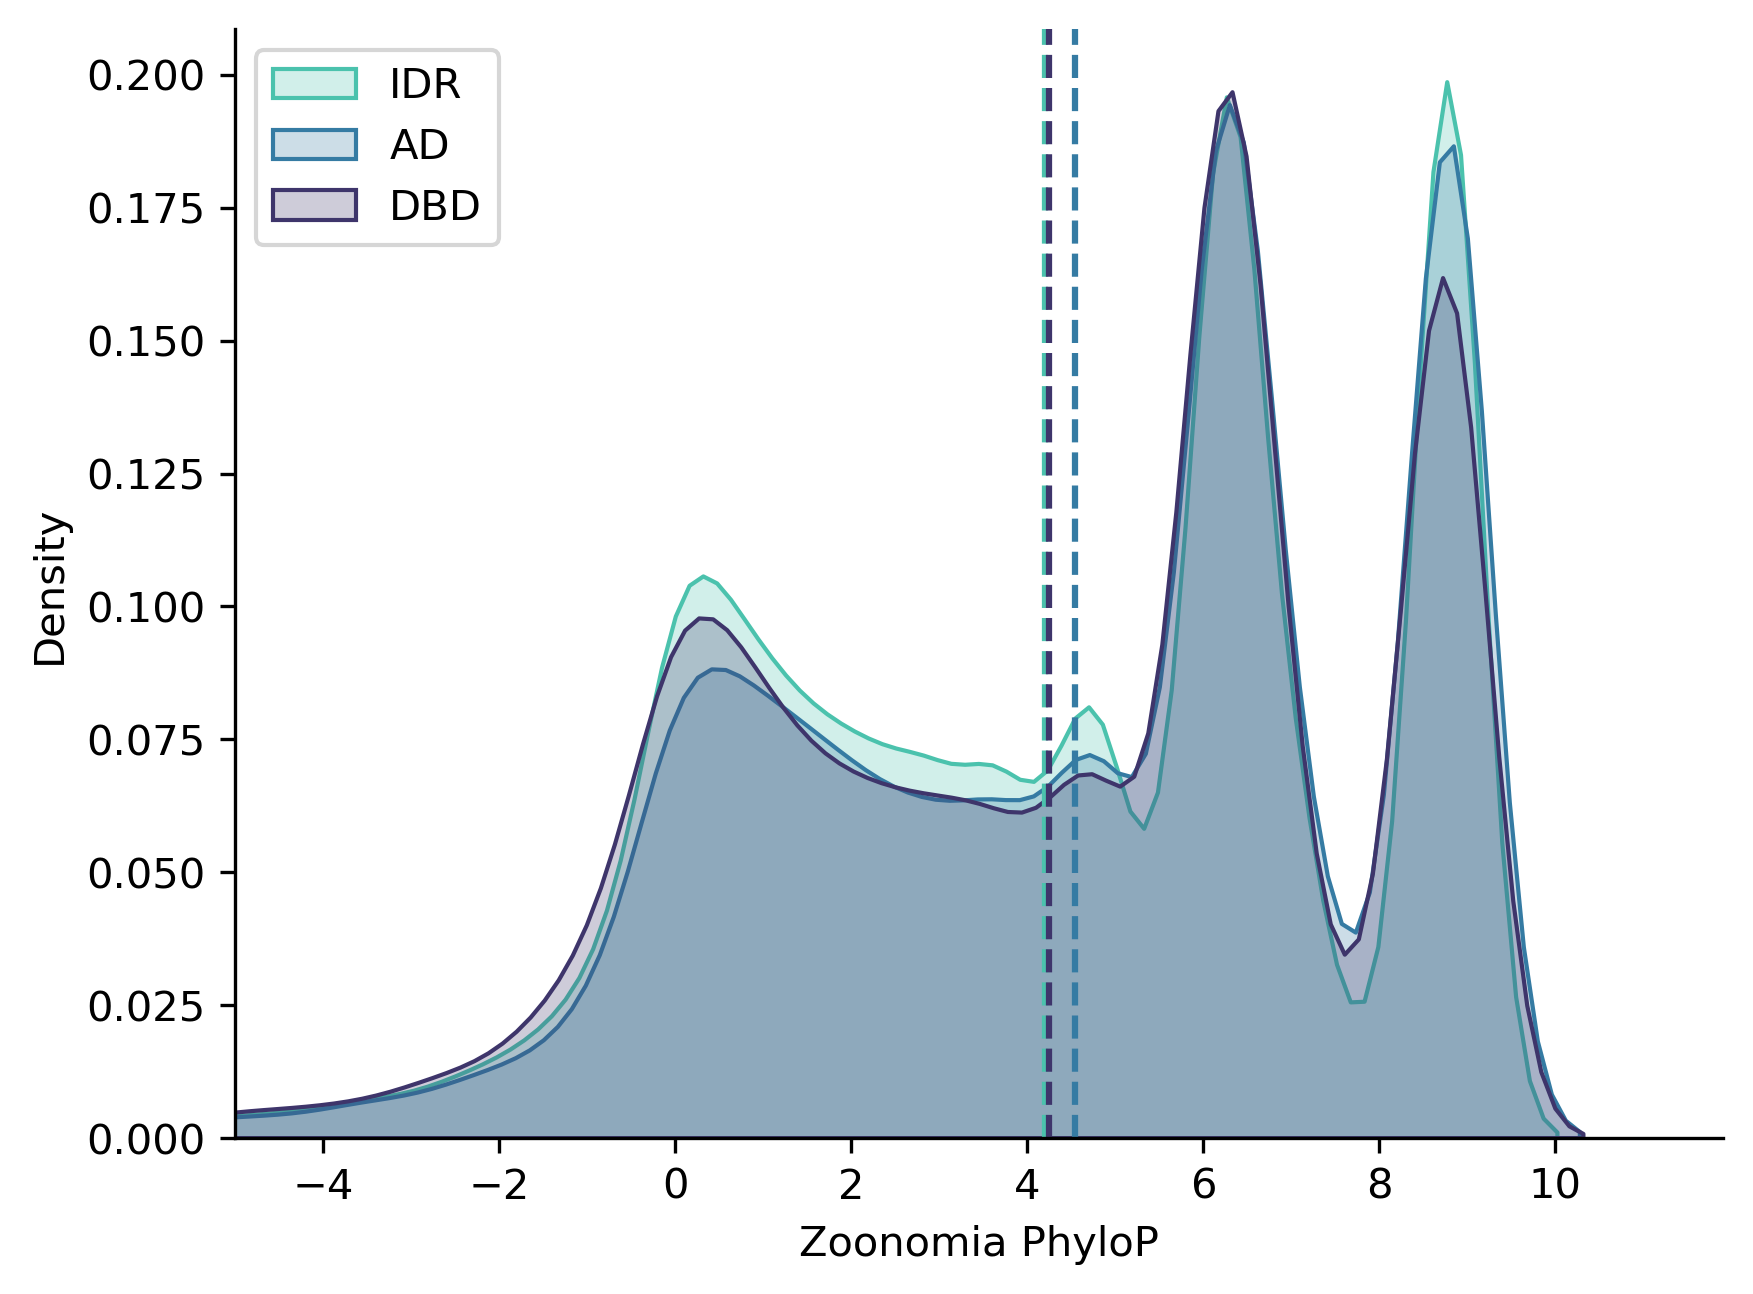

In [9]:
color_palette = sns.color_palette('mako', 3)

plt.figure(dpi=300, facecolor='none')

sns.kdeplot(zoonomia_domains[zoonomia_domains[3] == "IDR"][16], label="IDR", color=color_palette[2], fill=True)
plt.axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "IDR"][16]), color=color_palette[2], linestyle="--")

sns.kdeplot(zoonomia_domains[zoonomia_domains[3] == "AD"][16], label="AD", color=color_palette[1], fill=True)
plt.axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "AD"][16]), color=color_palette[1], linestyle="--")

sns.kdeplot(zoonomia_domains[zoonomia_domains[3] == "DBD"][16], label="DBD", color=color_palette[0], fill=True)
plt.axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "DBD"][16]), color=color_palette[0], linestyle="--")

plt.xlim(-5, None)
plt.legend(loc='upper left')
plt.xlabel("Zoonomia PhyloP")
sns.despine()

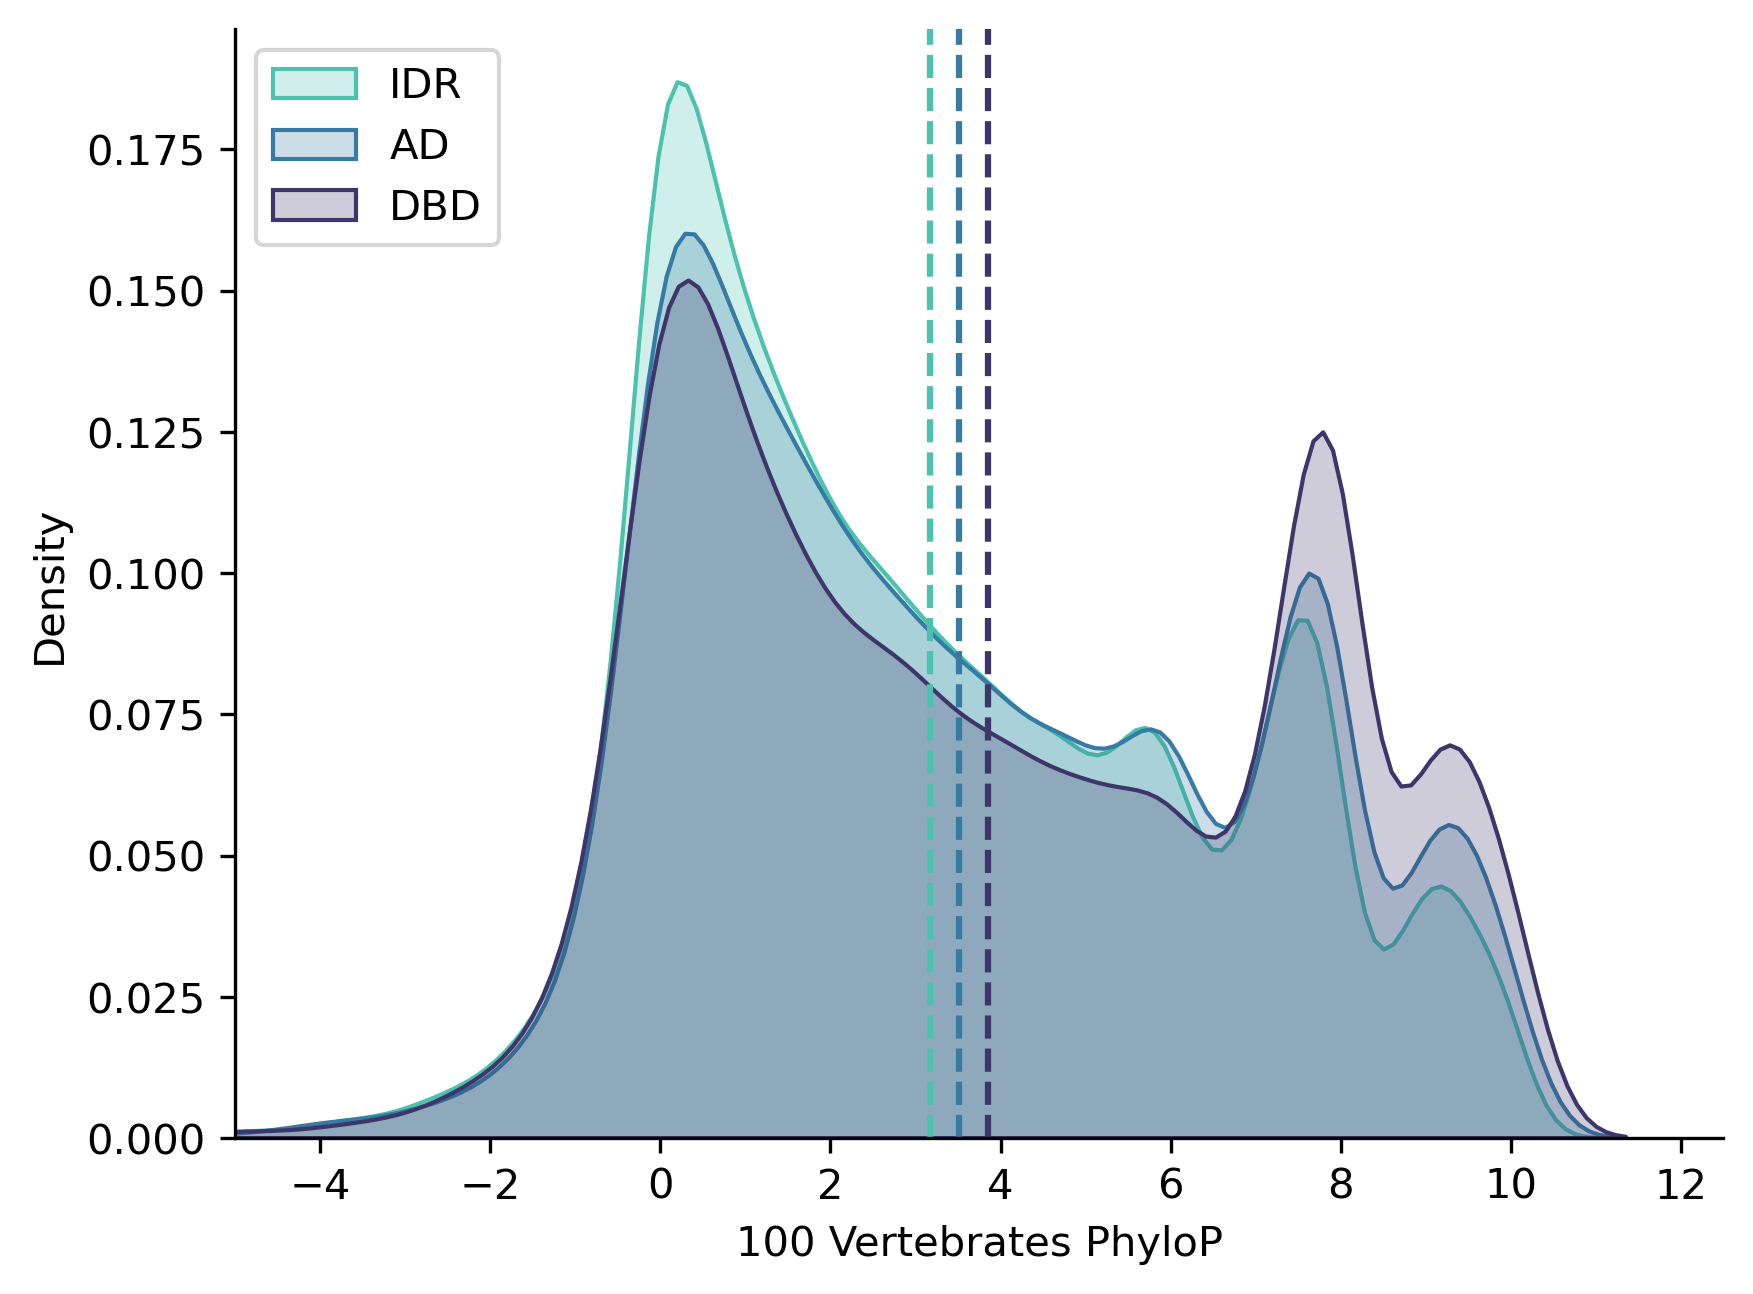

In [10]:
color_palette = sns.color_palette('mako', 3)

plt.figure(dpi=300, facecolor='none')

sns.kdeplot(verteb_domains[verteb_domains[3] == "IDR"][16], label="IDR", color=color_palette[2], fill=True)
plt.axvline(np.mean(verteb_domains[verteb_domains[3] == "IDR"][16]), color=color_palette[2], linestyle="--")

sns.kdeplot(verteb_domains[verteb_domains[3] == "AD"][16], label="AD", color=color_palette[1], fill=True)
plt.axvline(np.mean(verteb_domains[verteb_domains[3] == "AD"][16]), color=color_palette[1], linestyle="--")

sns.kdeplot(verteb_domains[verteb_domains[3] == "DBD"][16], label="DBD", color=color_palette[0], fill=True)
plt.axvline(np.mean(verteb_domains[verteb_domains[3] == "DBD"][16]), color=color_palette[0], linestyle="--")

plt.xlim(-5, None)
plt.legend(loc='upper left')
plt.xlabel("100 Vertebrates PhyloP")
sns.despine()


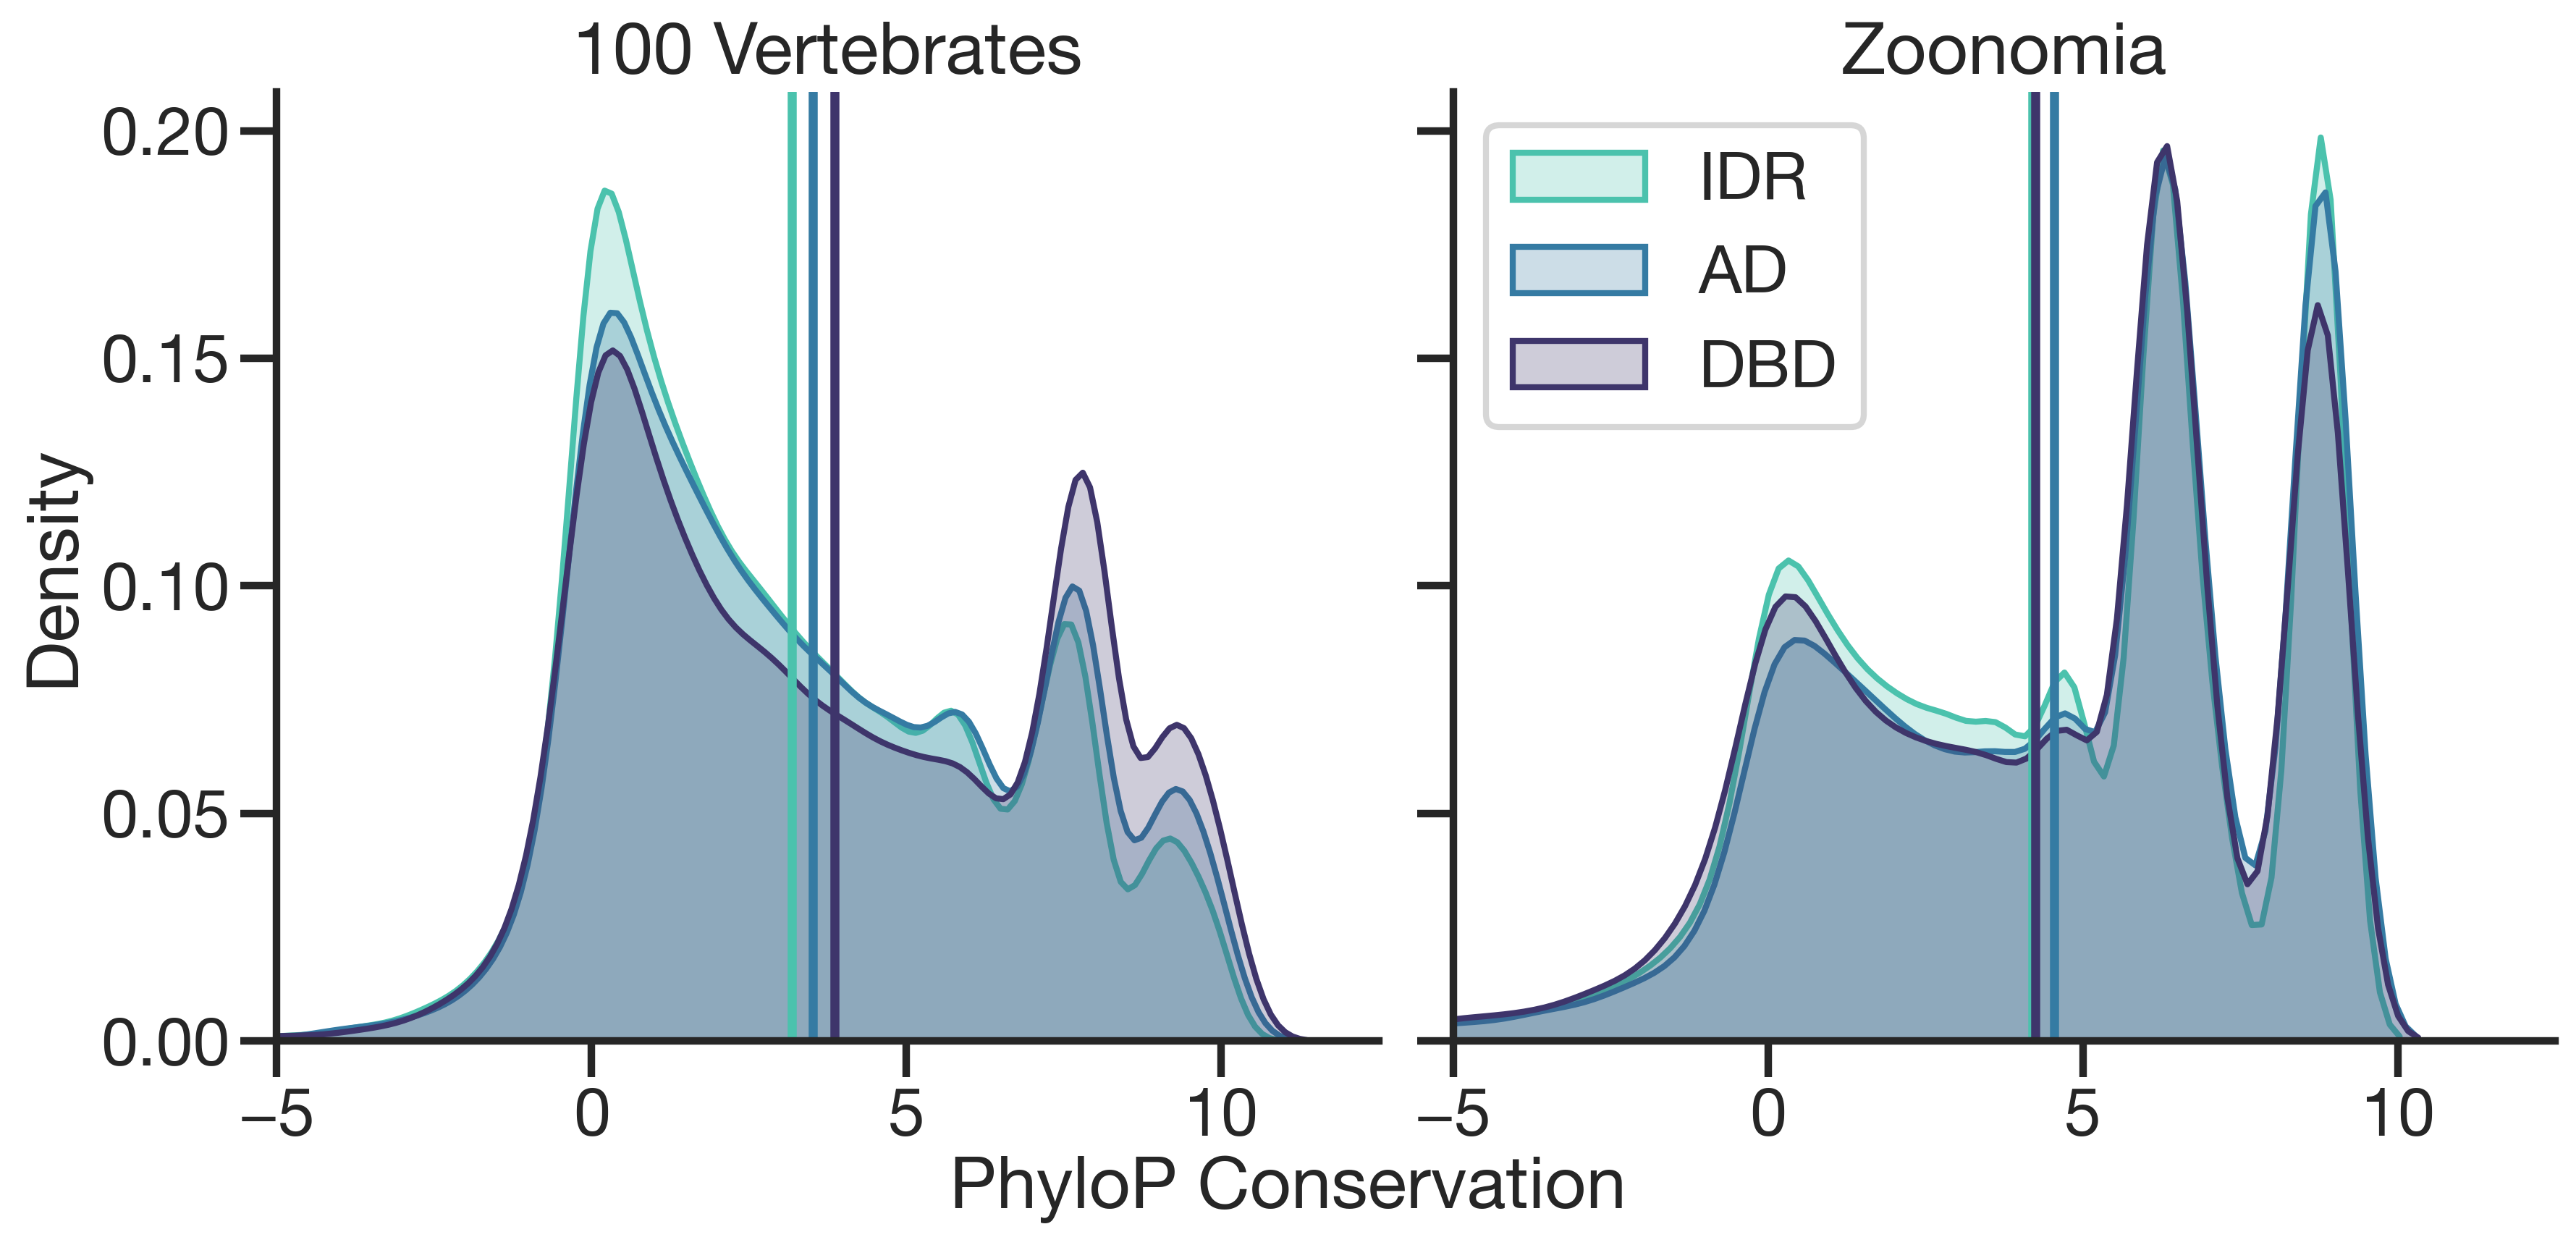

In [11]:
sns.set_context('poster')
sns.set_style('ticks')
plt.rcParams['font.family'] = 'Helvetica Neue'

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300, facecolor='none', sharex=True, sharey=True)

# Plot for 100 Vertebrates PhyloP
sns.kdeplot(verteb_domains[verteb_domains[3] == "IDR"][16], label="IDR", color=color_palette[2], fill=True, ax=axes[0])
axes[0].axvline(np.mean(verteb_domains[verteb_domains[3] == "IDR"][16]), color=color_palette[2], linestyle="-")

sns.kdeplot(verteb_domains[verteb_domains[3] == "AD"][16], label="AD", color=color_palette[1], fill=True, ax=axes[0])
axes[0].axvline(np.mean(verteb_domains[verteb_domains[3] == "AD"][16]), color=color_palette[1], linestyle="-")

sns.kdeplot(verteb_domains[verteb_domains[3] == "DBD"][16], label="DBD", color=color_palette[0], fill=True, ax=axes[0])
axes[0].axvline(np.mean(verteb_domains[verteb_domains[3] == "DBD"][16]), color=color_palette[0], linestyle="-")

axes[0].set_xlim(-5, None)
axes[0].set_title("100 Vertebrates")

# Plot for Zoonomia PhyloP
sns.kdeplot(zoonomia_domains[zoonomia_domains[3] == "IDR"][16], label="IDR", color=color_palette[2], fill=True, ax=axes[1])
axes[1].axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "IDR"][16]), color=color_palette[2], linestyle="-")

sns.kdeplot(zoonomia_domains[zoonomia_domains[3] == "AD"][16], label="AD", color=color_palette[1], fill=True, ax=axes[1])
axes[1].axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "AD"][16]), color=color_palette[1], linestyle="-")

sns.kdeplot(zoonomia_domains[zoonomia_domains[3] == "DBD"][16], label="DBD", color=color_palette[0], fill=True, ax=axes[1])
axes[1].axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "DBD"][16]), color=color_palette[0], linestyle="-")

axes[1].set_xlim(-5, None)
axes[1].set_title("Zoonomia")
axes[1].legend(loc='upper left')

sns.despine()

for ax in axes:
    ax.set_xlabel("")

fig.supxlabel("PhyloP Conservation", ha='center', y=0.05, fontsize='medium')
plt.tight_layout(pad = 0.5)

In [12]:
mtr_domains = return_big_df("../soto_analysis/outputs/mutations/domains_mtr/*")
# Filter to activator TFs
mtr_domains = mtr_domains[mtr_domains[7].isin(activator_TFs["ENST"])]
# Filter to SFARI TFs
mtr_domains = mtr_domains[mtr_domains[7].isin(old_SFARI_TF_dbd_coords["ENST"])]
mtr_domains_by_TF = mtr_domains.groupby([7, 3]).mean(numeric_only=True).reset_index()
mtr_domains_by_TF

,7,3,0,1,2,4,6,8,9,10,12,13,14,15,16
0,ENST00000056233,AD,7.0,2.618465e+07,2.618465e+07,NaN,1.0,7.0,2.618465e+07,2.618465e+07,1.0,7.0,2.618465e+07,2.618465e+07,1.011960
1,ENST00000056233,DBD,7.0,2.618552e+07,2.618552e+07,NaN,1.0,7.0,2.618552e+07,2.618552e+07,1.0,7.0,2.618552e+07,2.618552e+07,0.988435
2,ENST00000056233,IDR,7.0,2.617427e+07,2.617427e+07,NaN,1.0,7.0,2.617427e+07,2.617427e+07,1.0,7.0,2.617427e+07,2.617427e+07,0.993355
3,ENST00000239243,AD,5.0,1.747295e+08,1.747295e+08,NaN,1.0,5.0,1.747295e+08,1.747295e+08,1.0,5.0,1.747295e+08,1.747295e+08,0.926193
4,ENST00000239243,DBD,5.0,1.747293e+08,1.747293e+08,NaN,1.0,5.0,1.747293e+08,1.747293e+08,1.0,5.0,1.747293e+08,1.747293e+08,0.826027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,ENST00000561208,DBD,15.0,3.697755e+07,3.697755e+07,NaN,-1.0,15.0,3.697755e+07,3.697755e+07,-1.0,15.0,3.697755e+07,3.697755e+07,0.547530
120,ENST00000561208,IDR,15.0,3.699765e+07,3.699765e+07,NaN,-1.0,15.0,3.699765e+07,3.699765e+07,-1.0,15.0,3.699765e+07,3.699765e+07,0.917484
121,ENST00000592199,AD,19.0,1.308883e+07,1.308883e+07,NaN,1.0,19.0,1.308883e+07,1.308883e+07,1.0,19.0,1.308883e+07,1.308883e+07,0.924588
122,ENST00000592199,DBD,19.0,1.302535e+07,1.302535e+07,NaN,1.0,19.0,1.302535e+07,1.302535e+07,1.0,19.0,1.302535e+07,1.302535e+07,0.507016


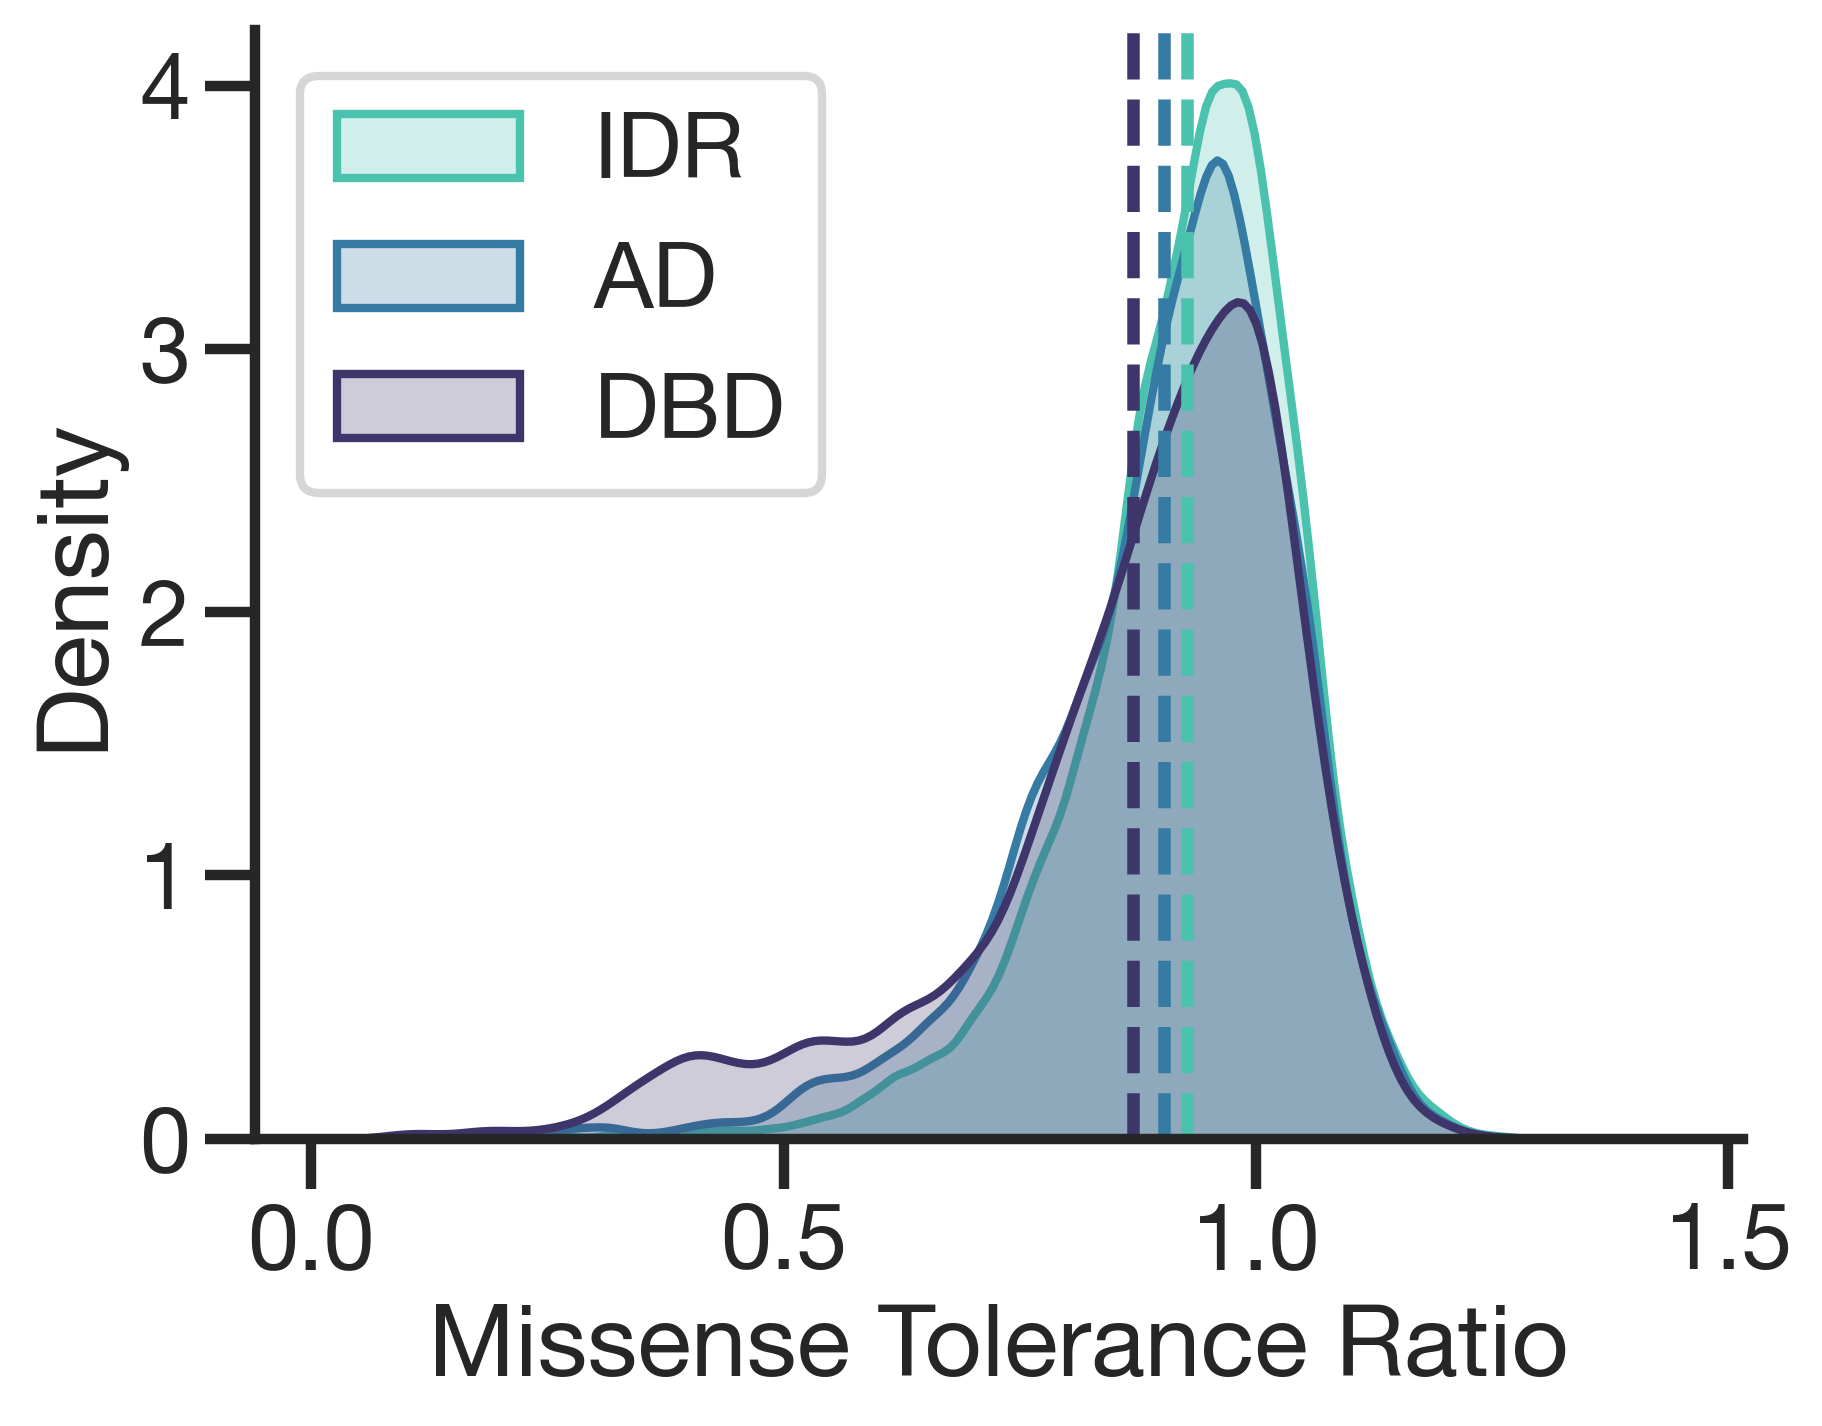

In [13]:
color_palette = sns.color_palette('mako', 3)

plt.figure(dpi=300, facecolor='none')

sns.kdeplot(mtr_domains[mtr_domains[3] == "IDR"][16], label="IDR", color=color_palette[2], fill=True)
plt.axvline(np.mean(mtr_domains[mtr_domains[3] == "IDR"][16]), color=color_palette[2], linestyle="--")

sns.kdeplot(mtr_domains[mtr_domains[3] == "AD"][16], label="AD", color=color_palette[1], fill=True)
plt.axvline(np.mean(mtr_domains[mtr_domains[3] == "AD"][16]), color=color_palette[1], linestyle="--")

sns.kdeplot(mtr_domains[mtr_domains[3] == "DBD"][16], label="DBD", color=color_palette[0], fill=True)
plt.axvline(np.mean(mtr_domains[mtr_domains[3] == "DBD"][16]), color=color_palette[0], linestyle="--")

# plt.xlim(-5, None)
plt.legend(loc='upper left')
plt.xlabel("Missense Tolerance Ratio")
sns.despine()


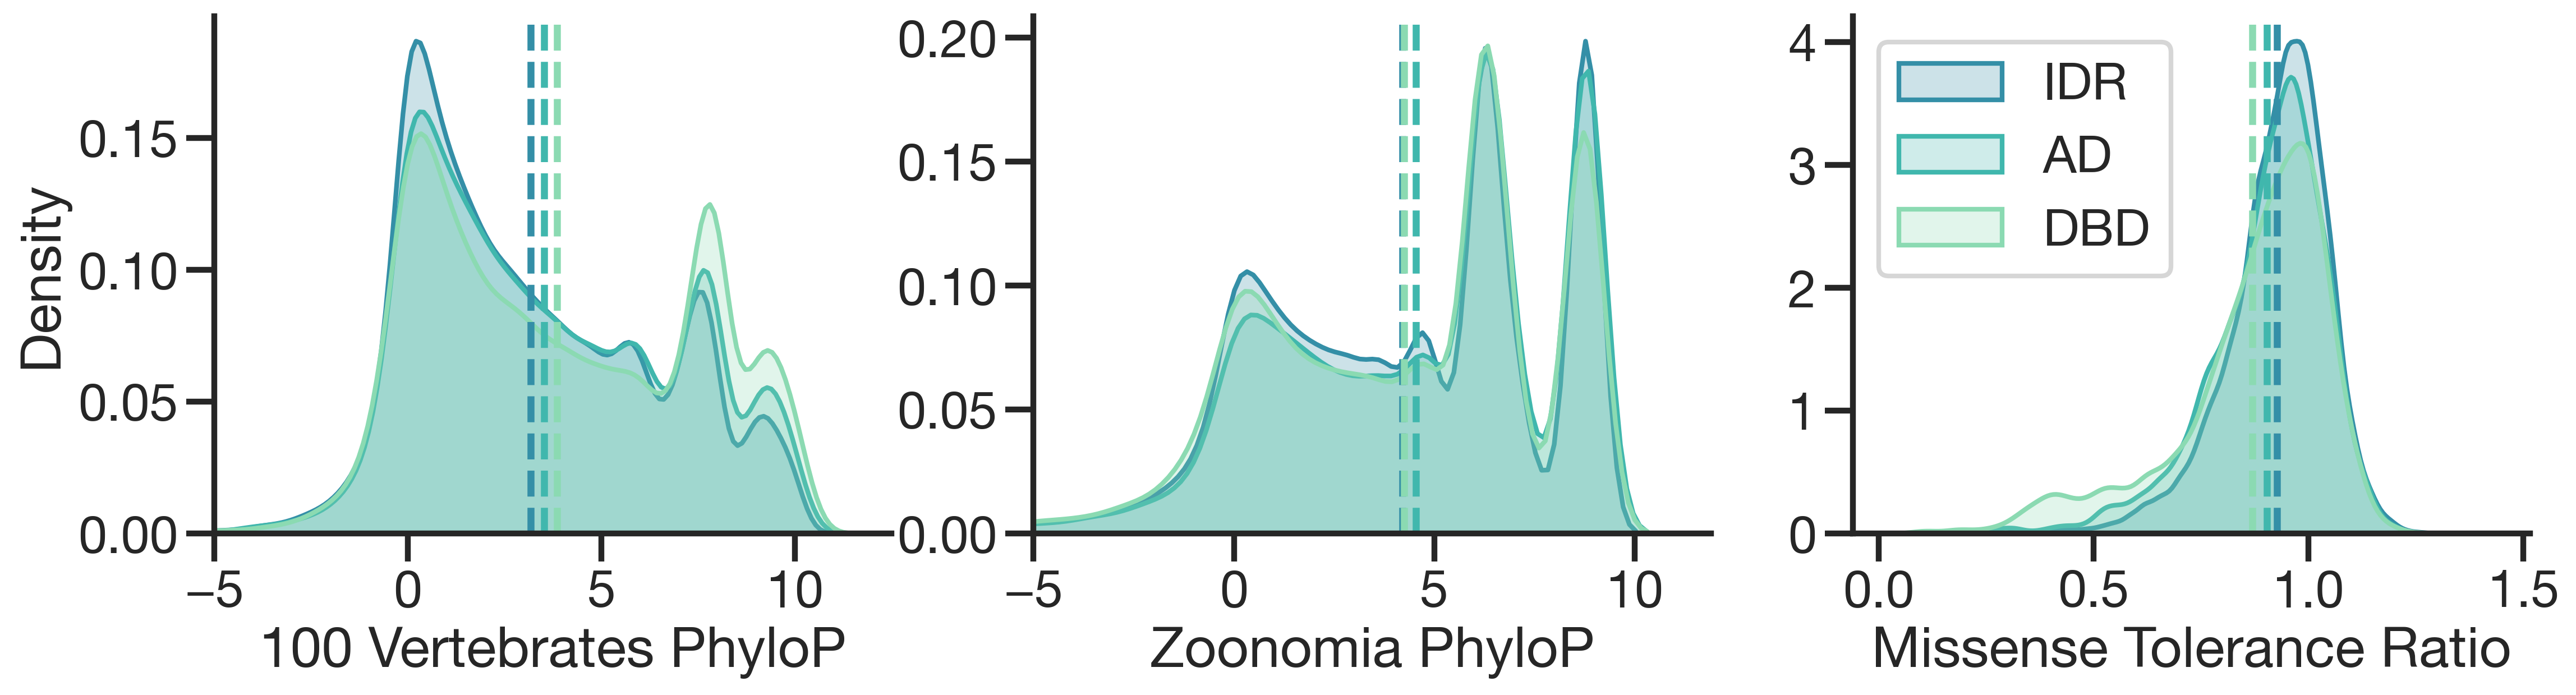

In [14]:
sns.set_context('poster')
sns.set_style('ticks')
plt.rcParams['font.family'] = 'Helvetica Neue'

color_palette = sns.color_palette('mako_r', 6)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=300, facecolor='none')

# Plot for 100 Vertebrates PhyloP
sns.kdeplot(verteb_domains[verteb_domains[3] == "IDR"][16], label="IDR", color=color_palette[2], fill=True, ax=axes[0])
axes[0].axvline(np.mean(verteb_domains[verteb_domains[3] == "IDR"][16]), color=color_palette[2], linestyle="--")

sns.kdeplot(verteb_domains[verteb_domains[3] == "AD"][16], label="AD", color=color_palette[1], fill=True, ax=axes[0])
axes[0].axvline(np.mean(verteb_domains[verteb_domains[3] == "AD"][16]), color=color_palette[1], linestyle="--")

sns.kdeplot(verteb_domains[verteb_domains[3] == "DBD"][16], label="DBD", color=color_palette[0], fill=True, ax=axes[0])
axes[0].axvline(np.mean(verteb_domains[verteb_domains[3] == "DBD"][16]), color=color_palette[0], linestyle="--")

axes[0].set_xlim(-5, None)

# Plot for Zoonomia PhyloP
sns.kdeplot(zoonomia_domains[zoonomia_domains[3] == "IDR"][16], label="IDR", color=color_palette[2], fill=True, ax=axes[1])
axes[1].axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "IDR"][16]), color=color_palette[2], linestyle="--")

sns.kdeplot(zoonomia_domains[zoonomia_domains[3] == "AD"][16], label="AD", color=color_palette[1], fill=True, ax=axes[1])
axes[1].axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "AD"][16]), color=color_palette[1], linestyle="--")

sns.kdeplot(zoonomia_domains[zoonomia_domains[3] == "DBD"][16], label="DBD", color=color_palette[0], fill=True, ax=axes[1])
axes[1].axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "DBD"][16]), color=color_palette[0], linestyle="--")

axes[1].set_xlim(-5, None)

# Plot for Missense Tolerance Ratio
sns.kdeplot(mtr_domains[mtr_domains[3] == "IDR"][16], label="IDR", color=color_palette[2], fill=True, ax=axes[2])
axes[2].axvline(np.mean(mtr_domains[mtr_domains[3] == "IDR"][16]), color=color_palette[2], linestyle="--")

sns.kdeplot(mtr_domains[mtr_domains[3] == "AD"][16], label="AD", color=color_palette[1], fill=True, ax=axes[2])
axes[2].axvline(np.mean(mtr_domains[mtr_domains[3] == "AD"][16]), color=color_palette[1], linestyle="--")

sns.kdeplot(mtr_domains[mtr_domains[3] == "DBD"][16], label="DBD", color=color_palette[0], fill=True, ax=axes[2])
axes[2].axvline(np.mean(mtr_domains[mtr_domains[3] == "DBD"][16]), color=color_palette[0], linestyle="--")

axes[2].legend(loc='upper left')

sns.despine()

axes[0].set_xlabel("100 Vertebrates PhyloP")
axes[1].set_xlabel("Zoonomia PhyloP")
axes[2].set_xlabel("Missense Tolerance Ratio")

axes[1].set_ylabel("")
axes[2].set_ylabel("")

plt.tight_layout(pad=0.1)


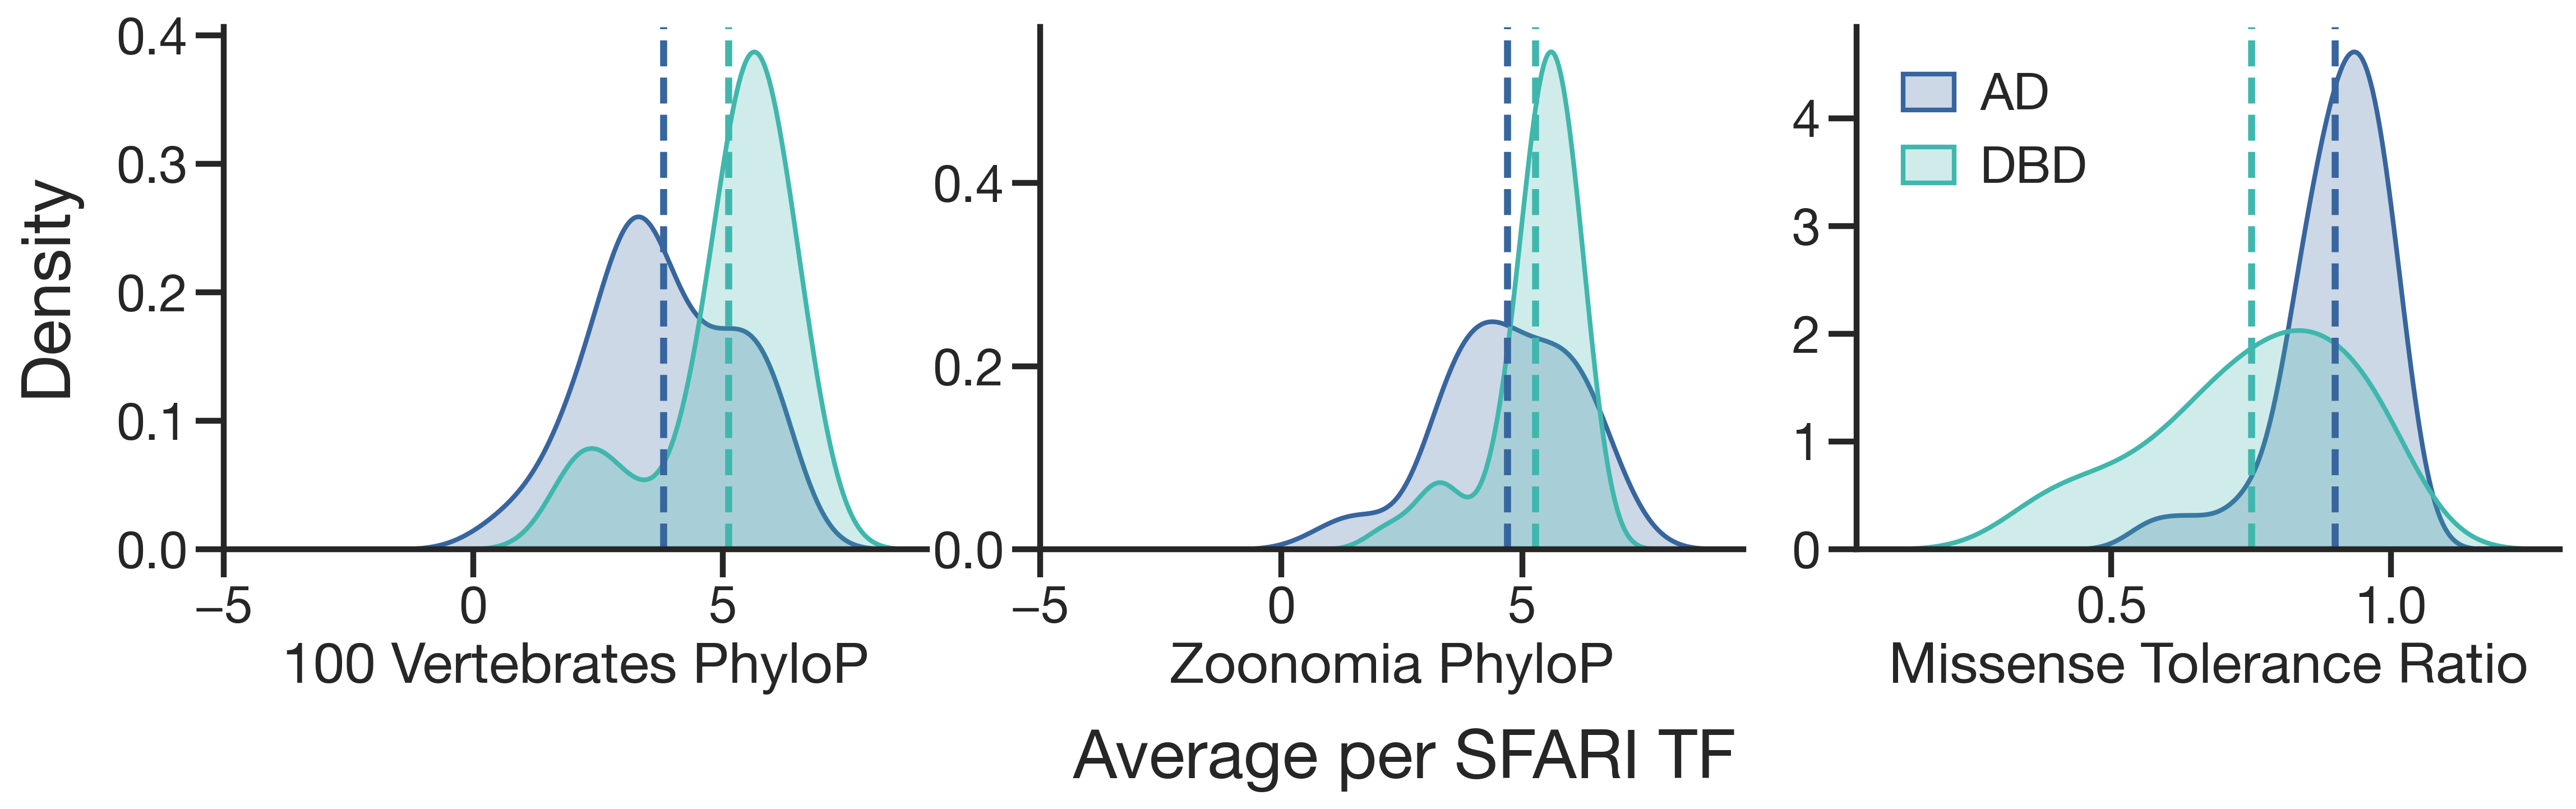

In [55]:
sns.set_context('poster')
sns.set_style('ticks')
plt.rcParams['font.family'] = 'Helvetica Neue'

color_palette = sns.color_palette('mako_r', 6)[1:]
#color_palette = ["#56B4E9", "#CC79A7", "#999999"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=300, facecolor='none')

# Plot for 100 Vertebrates PhyloP
# sns.kdeplot(verteb_domains_by_TF[verteb_domains_by_TF[3] == "IDR"][16], label="IDR", color=color_palette[2], fill=True, ax=axes[0])
# axes[0].axvline(np.mean(verteb_domains_by_TF[verteb_domains_by_TF[3] == "IDR"][16]), color=color_palette[2], linestyle="--")

sns.kdeplot(verteb_domains_by_TF[verteb_domains_by_TF[3] == "AD"][16], label="AD", color=color_palette[2], fill=True, ax=axes[0])
axes[0].axvline(np.mean(verteb_domains_by_TF[verteb_domains_by_TF[3] == "AD"][16]), color=color_palette[2], linestyle="--")

sns.kdeplot(verteb_domains_by_TF[verteb_domains_by_TF[3] == "DBD"][16], label="DBD", color=color_palette[0], fill=True, ax=axes[0])
axes[0].axvline(np.mean(verteb_domains_by_TF[verteb_domains_by_TF[3] == "DBD"][16]), color=color_palette[0], linestyle="--")

axes[0].set_xlim(-5, None)

# Plot for Zoonomia PhyloP
# sns.kdeplot(zoonomia_domains_by_TF[zoonomia_domains_by_TF[3] == "IDR"][16], label="IDR", color=color_palette[2], fill=True, ax=axes[1])
# axes[1].axvline(np.mean(zoonomia_domains_by_TF[zoonomia_domains_by_TF[3] == "IDR"][16]), color=color_palette[2], linestyle="--")

sns.kdeplot(zoonomia_domains_by_TF[zoonomia_domains_by_TF[3] == "AD"][16], label="AD", color=color_palette[2], fill=True, ax=axes[1])
axes[1].axvline(np.mean(zoonomia_domains_by_TF[zoonomia_domains_by_TF[3] == "AD"][16]), color=color_palette[2], linestyle="--")

sns.kdeplot(zoonomia_domains_by_TF[zoonomia_domains_by_TF[3] == "DBD"][16], label="DBD", color=color_palette[0], fill=True, ax=axes[1])
axes[1].axvline(np.mean(zoonomia_domains_by_TF[zoonomia_domains_by_TF[3] == "DBD"][16]), color=color_palette[0], linestyle="--")

axes[1].set_xlim(-5, None)

# Plot for Missense Tolerance Ratio
# sns.kdeplot(mtr_domains_by_TF[mtr_domains_by_TF[3] == "IDR"][16], label="IDR", color=color_palette[2], fill=True, ax=axes[2])
# axes[2].axvline(np.mean(mtr_domains_by_TF[mtr_domains_by_TF[3] == "IDR"][16]), color=color_palette[2], linestyle="--")

sns.kdeplot(mtr_domains_by_TF[mtr_domains_by_TF[3] == "AD"][16], label="AD", color=color_palette[2], fill=True, ax=axes[2])
axes[2].axvline(np.mean(mtr_domains_by_TF[mtr_domains_by_TF[3] == "AD"][16]), color=color_palette[2], linestyle="--")

sns.kdeplot(mtr_domains_by_TF[mtr_domains_by_TF[3] == "DBD"][16], label="DBD", color=color_palette[0], fill=True, ax=axes[2])
axes[2].axvline(np.mean(mtr_domains_by_TF[mtr_domains_by_TF[3] == "DBD"][16]), color=color_palette[0], linestyle="--")

axes[2].legend(loc='upper left', handletextpad=0.5, handlelength=1, frameon=False)

sns.despine()

axes[0].set_xlabel("100 Vertebrates PhyloP")
axes[1].set_xlabel("Zoonomia PhyloP")
axes[2].set_xlabel("Missense Tolerance Ratio")
fig.supxlabel("Average per SFARI TF", y = -0.03, x= 0.54)

axes[0].set_ylabel("")
axes[1].set_ylabel("")
axes[2].set_ylabel("")
fig.supylabel("Density", x= -0.01, y = 0.64)


plt.tight_layout(pad=0.1)


In [51]:
list(sns.color_palette("mako"))

[(0.18195582, 0.11955283, 0.23136943),
 (0.25307401, 0.23772973, 0.48316271),
 (0.21607792, 0.39736958, 0.61948028),
 (0.20344718, 0.56074869, 0.65649508),
 (0.25187832, 0.71827158, 0.67872193),
 (0.54578602, 0.8544913, 0.69848331)]